In [212]:
from cil.io import ZEISSDataReader
import numpy as np
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader
import plotly.graph_objects as go
import plot_library as pl
from scipy.ndimage import rotate
from scipy.interpolate import griddata
import SimpleITK as sitk

In [213]:
reconpath0 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"
reconpath_neutron = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/P20212875_Nice data/04_evaluation/fullrecon"

In [214]:
reader = ZEISSDataReader(reconpath0)
recon_xray_ = reader.read()
recon_xray = pl.array_normalizer(recon_xray_.as_array().astype(np.float32))

In [215]:
roi = {'axis_0': (100, 1113, 1)}
reader = TIFFStackReader(reconpath_neutron,roi=roi)
recon_neutron = pl.array_normalizer(reader.read())

In [355]:
class Registrator():

    def __init__(self, fixed_data=None, moving_data=None):
        self.fixed = fixed_data
        self.moving = moving_data

    def add_data(self, fixed_data=None, moving_data=None):
        self.fixed = fixed_data
        self.moving = moving_data
        
    def downsize(self,block_size = (30,30,30), final_size_target = None ,fixed_or_moving = 'fixed'):
        if fixed_or_moving == 'fixed':
            matrix = self.fixed
        elif fixed_or_moving == 'moving':
            matrix = self.moving
        else:
            raise ValueError('Specify fixed or moving')
        if final_size_target is not None:
            block_size = (np.max(matrix.shape)//final_size_target, np.max(matrix.shape)//final_size_target,np.max(matrix.shape)//final_size_target)
        print(block_size)
        # Calculate the padding needed to make each dimension a multiple of 20
        pad_x = (block_size[0] - matrix.shape[0] % block_size[0]) % block_size[0]
        pad_y = (block_size[1] - matrix.shape[1] % block_size[1]) % block_size[1]
        pad_z = (block_size[2] - matrix.shape[2] % block_size[2]) % block_size[2]

        # Pad the matrix with zeros to make its dimensions multiples of 20
        padded_matrix = np.pad(matrix, ((0, pad_x), (0, pad_y), (0, pad_z)), mode='constant', constant_values=0)

        # Reshape the padded matrix into blocks of 20x20x20
        reshaped_matrix = padded_matrix.reshape(
            padded_matrix.shape[0] // block_size[0], block_size[0],
            padded_matrix.shape[1] // block_size[1], block_size[1],
            padded_matrix.shape[2] // block_size[2], block_size[2]
        )

        # Take the mean across the 20x20x20 blocks
        downsized_matrix = reshaped_matrix.mean(axis=(1, 3, 5))
        if fixed_or_moving == 'fixed':
            self.fixed_d = downsized_matrix
        else:
            self.moving_d  =downsized_matrix

    def thresholder(self, threshold = 0.5, fixed_or_moving = 'fixed', plot=False, downsized = False):
        if downsized:
            if fixed_or_moving == 'fixed':
                self.fixed_d_mask = (self.fixed_d>threshold)*1.0
                if plot:
                    middle = np.shape(self.fixed_d)[0]//2
                    plt.imshow(self.fixed_d_mask[middle])
                    plt.show()
            elif fixed_or_moving == 'moving':
                self.moving_d_mask = (self.moving_d>threshold)*1.0
                if plot:
                    middle = np.shape(self.moving_d)[0]//2
                    plt.imshow(self.moving_d_mask[middle])
                    plt.show()
        else:
            if fixed_or_moving == 'fixed':
                self.fixed_mask = (self.fixed>threshold)*1.0
                if plot:
                    middle = np.shape(self.fixed)[0]//2
                    plt.imshow(self.fixed_mask[middle])
                    plt.show()
            elif fixed_or_moving == 'moving':
                self.moving_mask = (self.moving>threshold)*1.0
                if plot:
                    middle = np.shape(self.moving)[0]//2
                    plt.imshow(self.moving_mask[middle])
                    plt.show()

    def GetImageFromArray(self):
        if self.fixed is not None:
            self.IM_fixed = sitk.GetImageFromArray(self.fixed)
        if self.moving is not None:
            self.IM_moving = sitk.GetImageFromArray(self.moving)
        if self.fixed_d is not None:
            self.IM_fixed_d = sitk.GetImageFromArray(self.fixed_d)
        if self.moving_d is not None:
            self.IM_moving_d = sitk.GetImageFromArray(self.moving_d)

        if self.fixed_mask is not None:
            self.IM_fixed_mask = sitk.GetImageFromArray(self.fixed_mask)
        if self.moving_mask is not None:
            self.IM_moving_mask = sitk.GetImageFromArray(self.moving_mask)
        if self.fixed_d_mask is not None:
            self.IM_fixed_d_mask = sitk.GetImageFromArray(self.fixed_d_mask)
        if self.moving_d_mask is not None:
            self.IM_moving_d_mask = sitk.GetImageFromArray(self.moving_d_mask)

    def set_main(self,downsized = False, mask = True):
        if mask:
            if downsized:
                self.reference = self.fixed_d_mask
                self.adjust = self.moving_d_mask
            else:
                self.reference = self.fixed_mask
                self.adjust = self.moving_mask
        else:
            if downsized:
                self.reference = self.fixed_d
                self.adjust = self.moving_d
            else:
                self.reference = self.fixed
                self.adjust = self.moving

        self.reference = sitk.GetImageFromArray(self.reference)
        self.adjust = sitk.GetImageFromArray(self.adjust)

    def transform_initial(self):
        initial_transform = sitk.CenteredTransformInitializer(
        self.reference,                  # Reference (fixed) image
        self.adjust,                     # Moving (adjust) image
        sitk.Similarity3DTransform(),    # Use similarity transformation (translation, rotation, scaling)
        sitk.CenteredTransformInitializerFilter.GEOMETRY  # Align the centroids (geometry)
        )
        resampler = sitk.ResampleImageFilter()
        resampler.SetReferenceImage(self.reference)  # Reference image (fixed)
        resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
        resampler.SetTransform(initial_transform)    # Apply the initial transform (aligned centroids)
        self.adjust = resampler.Execute(self.adjust)  # Resample the moving image

    def apply_similarity_transform(self, matrix,translation,scale):
        """
        Applies a Similarity3DTransform to a moving image using the provided transformation parameters.
        
        :param moving_image: The moving image to which the transformation is applied.
        :param rx, ry, rz: Rotation angles in radians.
        :param tx, ty, tz: Translation values in mm.
        :param scale: Scaling factor (uniform).
        :return: Transformed moving image.
        """
        fixed_image = self.reference
        moving_image = self.adjust
        # Initialize a Similarity3DTransform and set its parameters
        similarity_transform = sitk.Similarity3DTransform()
        similarity_transform.SetMatrix(matrix)
        similarity_transform.SetTranslation(translation)
        #similarity_transform.SetScale(scale)

        # Resample the moving image with the specified transformation
        #resampler = sitk.ResampleImageFilter()
        #resampler.SetTransform(similarity_transform)
        #resampler.SetSize(moving_image.GetSize())
        #resampler.SetOutputOrigin(moving_image.GetOrigin())
        #resampler.SetOutputSpacing(moving_image.GetSpacing())
        #resampler.SetOutputDirection(moving_image.GetDirection())
        #resampler.SetInterpolator(sitk.sitkLinear)

        # Apply the transformation and return the transformed image
        #self.adjust = resampler.Execute(moving_image)
        self.adjust = sitk.Resample(self.adjust, self.reference, similarity_transform, 
                                         sitk.sitkLinear, 0.0, self.reference.GetPixelID())


    def SetupRegistration(self):

        self.Reg = sitk.ImageRegistrationMethod()
        self.Reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=100)
        self.Reg.SetMetricSamplingStrategy(self.Reg.RANDOM)
        self.Reg.SetMetricSamplingPercentage(0.5)

        # Use a multi-resolution pyramid
        self.Reg.SetShrinkFactorsPerLevel([2, 2, 1])
        self.Reg.SetSmoothingSigmasPerLevel([10, 5, 0])
        # Configure the rigid transform for rotation and translation
        #initial_transform = sitk.CenteredTransformInitializer(
        #    self.reference,
        #    self.adjust,
        #    sitk.Similarity2DTransform() if self.reference.GetDimension() == 2 else sitk.Similarity3DTransform(),
        #    sitk.CenteredTransformInitializerFilter.GEOMETRY
        #)
        self.Reg.SetInitialTransform(sitk.Similarity3DTransform(), inPlace=False)
        self.Reg.SetOptimizerAsGradientDescent(learningRate=0.1,
                                        numberOfIterations=2000,
                                        convergenceMinimumValue=1e-6,
                                            convergenceWindowSize=10)
        
        #self.Reg.SetOptimizerAsLBFGSB(gradientConvergenceTolerance=1e-5,
        #                                numberOfIterations=500,
        #                                maximumNumberOfCorrections=5)

        self.Reg.SetOptimizerScalesFromPhysicalShift()
        self.Reg.SetInterpolator(sitk.sitkLinear)

    def ExecuteRegistration(self):
        self.registration_transform = self.Reg.Execute(self.reference, self.adjust)

    def get_transformation_parameters(self):
        if isinstance(self.registration_transform, sitk.CompositeTransform):
            # Get the first sub-transform, which should be the actual one applied
            final_transform = self.registration_transform.GetNthTransform(0)
        else:
            final_transform = self.registration_transform

        # Now print the parameters based on the actual transform type
        print("Base Transformation Type:", type(final_transform))
        if isinstance(final_transform, sitk.Euler2DTransform):
            angle, tx, ty = final_transform.GetParameters()
            return angle, tx, ty, type(final_transform)
        elif isinstance(final_transform, sitk.Similarity2DTransform):
            scale, angle, tx, ty = final_transform.GetParameters()
            return scale, angle, tx, ty, type(final_transform)
        elif isinstance(final_transform, sitk.Euler3DTransform):
            rx, ry, rz, tx, ty, tz = final_transform.GetParameters()
            return  rx, ry, rz, tx, ty, tz, type(final_transform)
        elif isinstance(final_transform, sitk.Similarity3DTransform):
            rx, ry, rz, tx, ty, tz, scale = final_transform.GetParameters()
            return rx, ry, rz, tx, ty, tz, scale, type(final_transform)

    def resample(self):         
        self.resampled = sitk.Resample(self.adjust, self.reference, self.registration_transform, 
                                         sitk.sitkLinear, 0.0, self.reference.GetPixelID())
        

    def convert_to_array(self, image):
        return sitk.GetArrayFromImage(image)
    

    def rotate_about_yz_plane(self, angle_degrees,axis='x'):
        # Convert angle from degrees to radians
        angle_radians = np.deg2rad(angle_degrees)

        # Calculate the rotation matrix for rotation about the X-axis
        if axis.lower() == 'x':
            rotation_matrix = [
                [1, 0, 0],
                [0, np.cos(angle_radians), -np.sin(angle_radians)],
                [0, np.sin(angle_radians), np.cos(angle_radians)]
            ]
        elif axis.lower() == 'y':
            rotation_matrix = [
                [np.cos(angle_radians), 0, np.sin(angle_radians)],
                [0, 1, 0],
                [-np.sin(angle_radians), 0, np.cos(angle_radians)]
            ]
        elif axis.lower() == 'z':
            rotation_matrix = [
                [np.cos(angle_radians), -np.sin(angle_radians), 0],
                [np.sin(angle_radians), np.cos(angle_radians), 0],
                [0, 0, 1]
            ]
        else:
            raise ValueError("Invalid axis. Choose from 'x', 'y', or 'z'.")

        # Get the center of the image
        image_center = [
            size / 2.0 * spacing
            for size, spacing in zip(self.adjust.GetSize(), self.adjust.GetSpacing())
        ]

        # Create a Similarity3DTransform
        transform = sitk.Similarity3DTransform()
        
        # Set the center of rotation
        transform.SetCenter(image_center)
        
        # Set the rotation matrix
        transform.SetMatrix([elem for row in rotation_matrix for elem in row])
        
        # Resample the image using the transform
        resampler = sitk.ResampleImageFilter()
        resampler.SetReferenceImage(self.adjust)
        resampler.SetInterpolator(sitk.sitkLinear)
        resampler.SetTransform(transform)

        # Perform the resampling
        self.adjust = resampler.Execute(self.adjust)
        
    def compute_principal_moments_and_axes(self):
        """
        Compute the principal moments and axes of inertia for a 3D image.

        Args:
            image (sitk.Image): The input 3D image (non-zero values are considered part of the region).

        Returns:
            tuple: A tuple containing:
                - principal_moments (list of float): The eigenvalues of the inertia matrix.
                - principal_axes (list of list of float): The eigenvectors of the inertia matrix.
        """
        # Create a binary mask of the region
        binary_image = sitk.BinaryThreshold(self.adjust, lowerThreshold=0.1, upperThreshold=float("inf"), insideValue=1, outsideValue=0)

        # Use LabelShapeStatisticsImageFilter to calculate shape properties
        label_shape_filter = sitk.LabelShapeStatisticsImageFilter()
        label_shape_filter.Execute(binary_image)

        if label_shape_filter.GetNumberOfLabels() == 0:
            raise ValueError("The image has no non-zero pixels to calculate moments of inertia.")

        # Get principal moments and axes for label 1 (the only label in this case)
        principal_moments = label_shape_filter.GetPrincipalMoments(1)  # Eigenvalues
        principal_axes = label_shape_filter.GetPrincipalAxes(1)  # Eigenvectors (flattened)

        # Reshape principal axes into a 3x3 matrix
        principal_axes_matrix = np.array(principal_axes).reshape((3, 3))

        return principal_moments, principal_axes_matrix
    

    def get_largest_eigenvector(self,principal_moments, principal_axes,rank=1):
        """
        Get the eigenvector corresponding to the largest eigenvalue.

        Args:
            principal_moments (list of float): Eigenvalues (principal moments) of the inertia matrix.
            principal_axes (np.ndarray): Eigenvectors (principal axes) as a 3x3 matrix.

        Returns:
            np.ndarray: The eigenvector corresponding to the largest eigenvalue.
        """
        # Convert to NumPy arrays for easy manipulation
        principal_moments = np.array(principal_moments)
        principal_axes = np.array(principal_axes)

        # Sort eigenvalues and their corresponding eigenvectors
        sorted_indices = np.argsort(principal_moments)[::-1]  # Descending order
        sorted_eigenvectors = principal_axes[:, sorted_indices]

        # Get the eigenvector corresponding to the specified rank
        eigenvector = sorted_eigenvectors[:, rank - 1]

        return eigenvector
    

    def create_mirroring_transform(self,point, vector1, vector2):
        """
        Create a mirroring transformation around a plane specified by a point and two vectors.

        Args:
            point (tuple): A point on the plane (x0, y0, z0).
            vector1 (tuple): First vector spanning the plane (v1x, v1y, v1z).
            vector2 (tuple): Second vector spanning the plane (v2x, v2y, v2z).

        Returns:
            sitk.AffineTransform: A SimpleITK affine transformation for mirroring around the plane.
        """
        # Convert inputs to NumPy arrays
        point = np.array(point)
        vector1 = np.array(vector1)
        vector2 = np.array(vector2)

        # Calculate the normal vector of the plane
        normal = np.cross(vector1, vector2)
        normal = normal / np.linalg.norm(normal)  # Normalize the normal vector

        # Construct the reflection matrix
        n = normal.reshape(3, 1)  # Make the normal a column vector
        reflection_matrix = np.eye(3) - 2 * (n @ n.T)  # Reflection formula: I - 2 * (n * n^T)

        # Create a 4x4 homogeneous transformation matrix
        homogeneous_matrix = np.eye(4)
        homogeneous_matrix[:3, :3] = reflection_matrix  # Top-left 3x3 is the reflection matrix
        homogeneous_matrix[:3, 3] = -2 * (reflection_matrix @ point)  # Translation to account for the plane position

        # Convert to a SimpleITK affine transform
        sitk_transform = sitk.AffineTransform(3)
        sitk_transform.SetMatrix(homogeneous_matrix[:3, :3].flatten())  # Set the 3x3 matrix
        sitk_transform.SetTranslation(homogeneous_matrix[:3, 3])  # Set the translation vector
        self.adjust = sitk.Resample(self.adjust, self.reference, sitk_transform, 
                                         sitk.sitkLinear, 0.0, self.reference.GetPixelID())


    def get_centroid(self):
        """
        Calculate the centroid of the non-zero pixels of the image in physical space using SimpleITK.
        
        Args:
            image (sitk.Image): The input 3D image.
            
        Returns:
            list: The [x, y, z] physical coordinates of the centroid.
        """
        # Create a binary mask (non-zero values are considered the ROI)
        binary_image = sitk.BinaryThreshold(self.adjust, lowerThreshold=1, upperThreshold=float("inf"), insideValue=1, outsideValue=0)

        # Use LabelShapeStatisticsImageFilter to calculate the centroid
        label_shape_filter = sitk.LabelShapeStatisticsImageFilter()
        label_shape_filter.Execute(binary_image)

        # Get the centroid of label 1 (the only label in this case)
        if label_shape_filter.GetNumberOfLabels() == 0:
            raise ValueError("The image has no non-zero pixels to calculate the centroid.")
        
        return list(label_shape_filter.GetCentroid(1))
            

In [356]:
recons = Registrator(fixed_data=recon_xray, moving_data=recon_neutron)
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'fixed')
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'moving')
print('Downsizing finished')
#recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = False)
recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = True)

#recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = False)
recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = True)

(10, 10, 10)
(10, 10, 10)
Downsizing finished


In [ ]:
recons.set_main(downsized = True, mask = True)
recons.transform_initial()
matrix = (0.8160936658664071, -0.28856459951138586, 0.02374979627874302, 0.2766920759330827, 0.7563278026519324, -0.31820151230511134, 0.08529405624244589, 0.3074754937003145, 0.8050007435556675)
translation = (15.245151809618564, 15.175912405966365, -20.850352829049456)
scale = 1.0 #0.8652125177637796
recons.apply_similarity_transform(matrix,translation,scale)
angle_degrees = 180
recons.rotate_about_yz_plane(angle_degrees,axis='x')

In [ ]:
#recons.SetupRegistration()
#recons.ExecuteRegistration()
#params = recons.get_transformation_parameters()
evals, evecs = recons.compute_principal_moments_and_axes()
principal1 = recons.get_largest_eigenvector(evals, evecs, rank = 1)
principal2 = recons.get_largest_eigenvector(evals, evecs, rank = 2)
centroid = recons.get_centroid()
print(principal1)
print(principal2)
print(centroid)
recons.create_mirroring_transform([0,0,0]], principal1, principal2)

[-0.1292231   0.18383061  0.97442686]
[ 0.94714112 -0.26810932  0.17618481]
[45.594781707719115, 51.91145857862761, 57.97386144209485]


In [ ]:
# Code: 
# Matrix: (0.8160936658664071, -0.28856459951138586, 0.02374979627874302, 0.2766920759330827, 0.7563278026519324, -0.31820151230511134, 0.08529405624244589, 0.3074754937003145, 0.8050007435556675)
# Versor:(0.18667249795024038, -0.01836190339688423, 0.16864592205798945, 0.9676645968443155)
# Translation: (15.245151809618564, 15.175912405966365, -20.850352829049456)
# Scale: 0.8652125177637796
# Center: (0.0, 0.0, 0.0)
#pars = recons.registration_transform.GetNthTransform(0).GetScale()
#print(pars)

0.9601310468710628


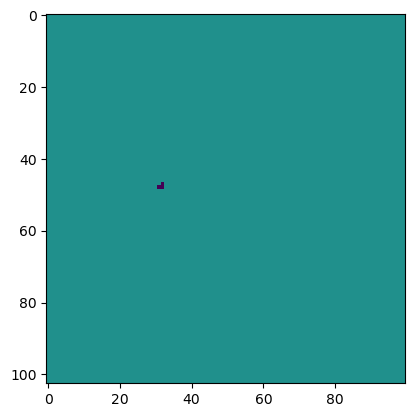

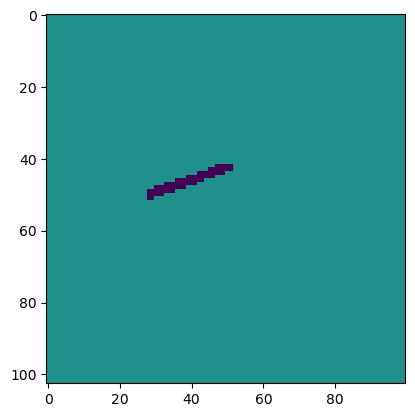

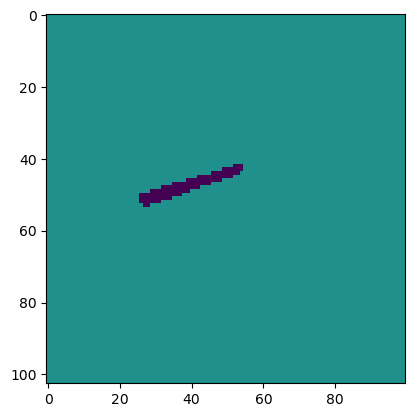

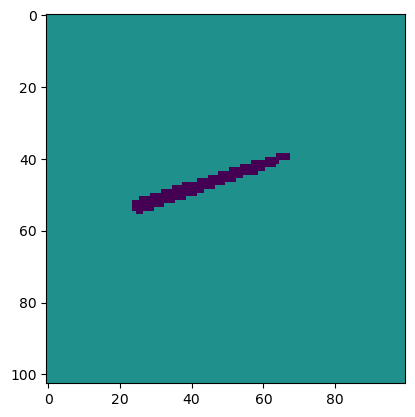

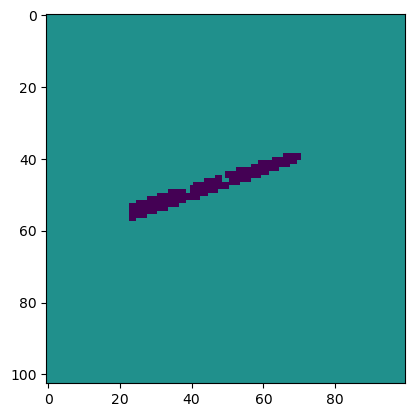

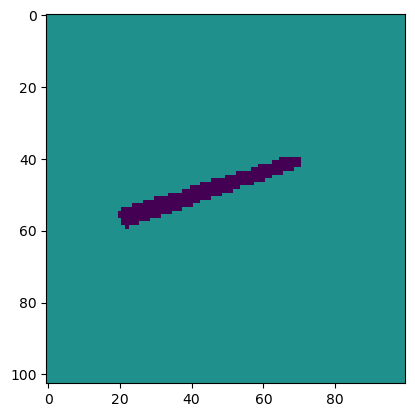

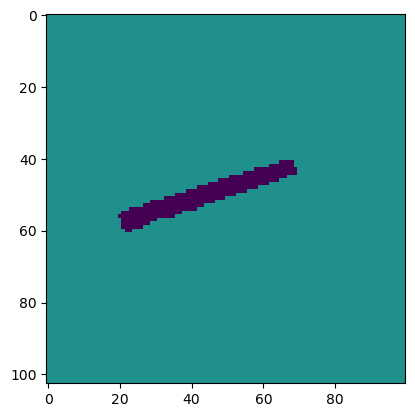

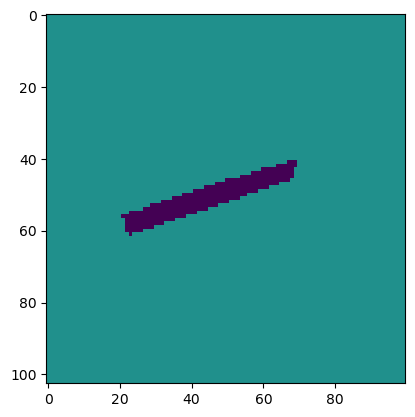

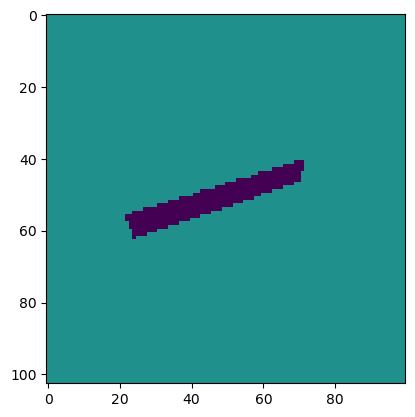

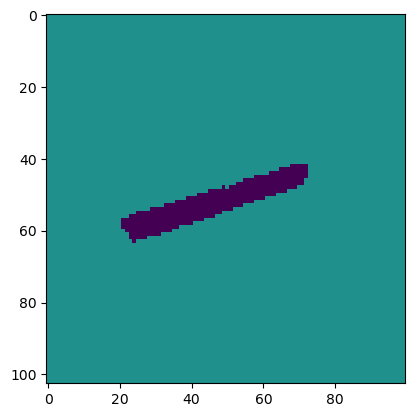

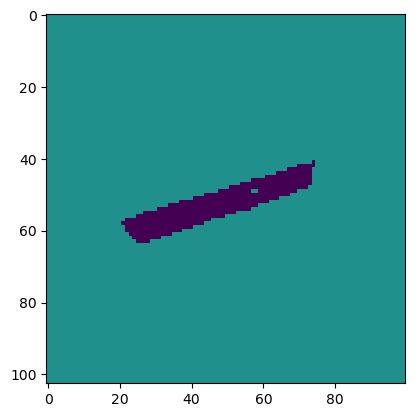

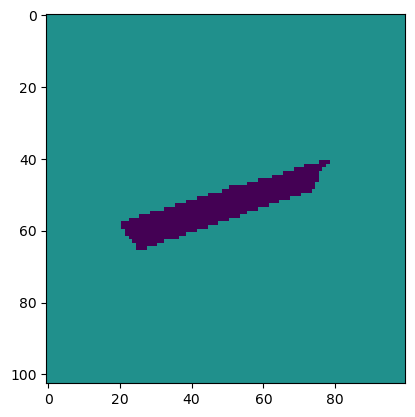

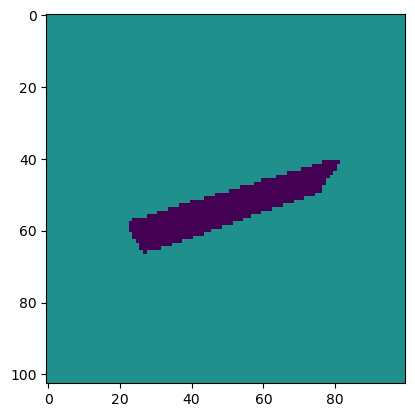

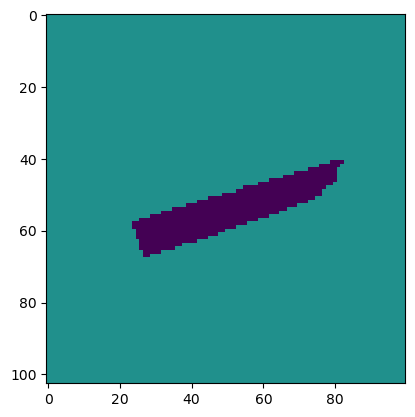

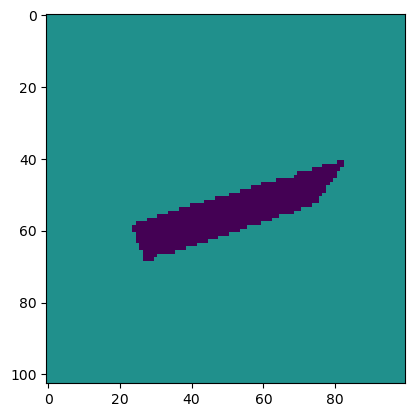

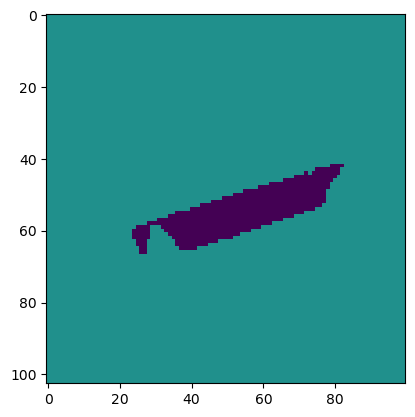

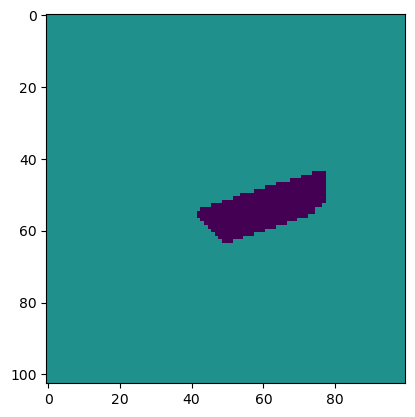

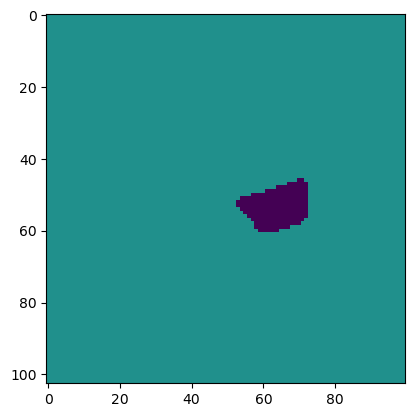

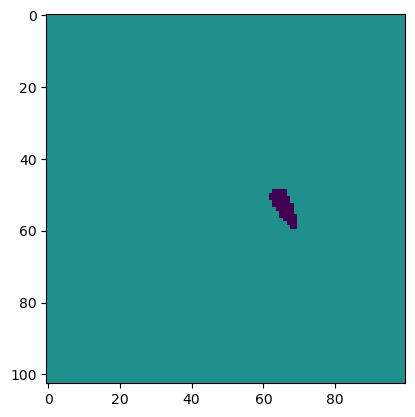

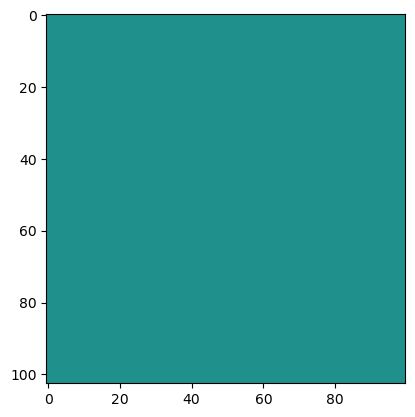

0.0
28591.0
28591.0


In [360]:
#recons.resample()
#recons.resample
moved = recons.convert_to_array(recons.adjust)
fixed = recons.fixed_d_mask

for slice_ in range(20):
    slice = slice_*5
    plt.imshow(moved[slice] - fixed[slice])
    plt.clim([-1,1])
    plt.show()
    #plt.imshow(moved[slice])
    #plt.show()
    #plt.imshow(fixed[slice])
    #plt.show()

print(np.sum(moved**2))
print(np.sum(fixed**2))
print(np.sum(np.abs(fixed-moved)))

In [ ]:

for slice_ in range(20):
    slice = slice_*5
    plt.imshow(moved[slice] - fixed[slice])
    plt.clim([-1,1])
    plt.show()
    #plt.imshow(moved[slice])
    #plt.show()
    #plt.imshow(fixed[slice])
    #plt.show()

print(np.sum(moved**2))
print(np.sum(fixed**2))
print(np.sum(fixed-moved)**2)